In [46]:
import os
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import glob
import os
import re
from tensorflow.keras import layers, models


In [47]:
threshold_offset = 80
num_thresholds = 3
random_thresholds = sorted(
    np.random.uniform(low=threshold_offset, high=2000.0, size=num_thresholds)
)

random_thresholds

[679.9667484687905, 1459.5134983301793, 1696.633832712877]

In [48]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer

pi = 3.14159265359

maxval=1e9
minval=1e-9

In [49]:
def extract_val_metric(fname):
    try:
        val_str = fname.split("-v-")[-1].replace(".hdf5", "")
        return float(val_str)
    except Exception:
        return float("-inf")



In [50]:
dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/"

NOISE_MU = 0.0
NOISE_SIGMA = 80.0 # e-

# tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", f"2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr")

tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", f"2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")


In [51]:
test_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=True,
)
labels_scale = test_generator.labels_scale
print(labels_scale)

Loading metadata from /depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/TFR_files/2t_N_0.0mu_80.0sig/TFR_val/metadata.json


[99.17029747 24.79370923  6.53245764  1.89031215]


In [52]:
# models_base_dir = f"/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr"
# models_base_dir = f"/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig"
models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr'

In [53]:
os.listdir(models_base_dir)

['Transformer_model-f5a9b141-checkpoints',
 'Transformer_model-a4bec5c0-checkpoints',
 'Transformer_model-6f7dba35-checkpoints',
 'Transformer_model-8c88a023-checkpoints',
 'Transformer_model-173ba0ee-checkpoints',
 'Transformer_model-0ec954dd-checkpoints',
 'Transformer_model-bdf24d1b-checkpoints',
 'Transformer_model-503ac40b-checkpoints']

In [54]:
dirs = glob.glob(os.path.join(models_base_dir, "Transformer_model-*-checkpoints"))
fingerprint_list = []
for d in dirs:
    m = re.search(r"Transformer_model-([a-f0-9]+)-checkpoints$", os.path.basename(d))
    if m:
        fingerprint_list.append(m.group(1))

print(fingerprint_list)

['f5a9b141', 'a4bec5c0', '6f7dba35', '8c88a023', '173ba0ee', '0ec954dd', 'bdf24d1b', '503ac40b']


In [55]:
import os
import pandas as pd

def get_first_mtime(path):
    """Return earliest modification time (approx creation) under path."""
    mtimes = []
    for root, _, files in os.walk(path):
        for f in files:
            full_path = os.path.join(root, f)
            try:
                mtimes.append(os.path.getmtime(full_path))
            except FileNotFoundError:
                continue
    if not mtimes:
        return None
    return min(mtimes)

all_results = []

for fingerprint in fingerprint_list:
    try:
        base_dir = os.path.join(models_base_dir, f"Transformer_model-{fingerprint}-checkpoints")
        checkpoints_dir = os.path.join(base_dir, "checkpoints")
        training_log = os.path.join(base_dir, "training_log.csv")
        quantizer_log = os.path.join(base_dir, "soft_quantizer_state_log.csv")
    
        # --- Load logs ---
        training_df = pd.read_csv(training_log)
        quant_df = pd.read_csv(quantizer_log)
    
        if len(training_df) != len(quant_df):
            raise ValueError(
                f"[{fingerprint}] Mismatch: training_log={len(training_df)}, quantizer_log={len(quant_df)}"
            )
    
        # --- Best checkpoint selection ---
        checkpoint_files = sorted(
            f for f in os.listdir(checkpoints_dir) if f.endswith((".hdf5", ".h5"))
        )
        checkpoint_files = [os.path.join(checkpoints_dir, f) for f in checkpoint_files]
    
        if not checkpoint_files:
            raise FileNotFoundError(f"[{fingerprint}] No checkpoint files found in {checkpoints_dir}")
    
        best_ckpt = max(checkpoint_files, key=lambda f: extract_val_metric(os.path.basename(f)))
        best_val = extract_val_metric(os.path.basename(best_ckpt))
    
        print(f"[{fingerprint}] Best checkpoint: {os.path.basename(best_ckpt)} (val={best_val:.4f})")
    
        # --- Merge training & quantizer logs ---
        df = training_df.copy()
        df["fingerprint"] = fingerprint
        df["best_val_metric"] = best_val
    
        for col in quant_df.columns:
            df[f"quantizer_{col}"] = quant_df[col].values
    
        # First modification timestamp
        first_mtime = get_first_mtime(base_dir)
        df["first_modified"] = pd.to_datetime(first_mtime, unit="s") if first_mtime else None
    
        all_results.append(df)
    except:
        continue

# === Final aggregation ===
final_df = pd.concat(all_results, ignore_index=True)

print("Final aggregated DataFrame shape:", final_df.shape)
print("Columns:", final_df.columns.tolist())


[f5a9b141] Best checkpoint: weights.01-t103033.83-v103006.63.hdf5 (val=-inf)
[a4bec5c0] Best checkpoint: weights.978-t-42446.16-v-44503.75.hdf5 (val=44503.7500)
[6f7dba35] Best checkpoint: weights.965-t-26771.49-v-27857.19.hdf5 (val=27857.1900)
[8c88a023] Best checkpoint: weights.994-t-42975.61-v-44628.55.hdf5 (val=44628.5500)
[173ba0ee] Best checkpoint: weights.979-t-42917.12-v-44780.99.hdf5 (val=44780.9900)
[0ec954dd] Best checkpoint: weights.94-t-35164.33-v-38224.70.hdf5 (val=38224.7000)
[bdf24d1b] Best checkpoint: weights.01-t103033.83-v103006.63.hdf5 (val=-inf)
[503ac40b] Best checkpoint: weights.998-t-42492.01-v-44416.14.hdf5 (val=44416.1400)
Final aggregated DataFrame shape: (5105, 22)
Columns: ['epoch', 'loss', 'val_loss', 'fingerprint', 'best_val_metric', 'quantizer_epoch', 'quantizer_k', 'quantizer_level_0', 'quantizer_level_1', 'quantizer_level_2', 'quantizer_level_3', 'quantizer_threshold_0', 'quantizer_threshold_1', 'quantizer_threshold_2', 'quantizer_raw_first_level', 'qu

In [56]:
def unnormalize_thresholds(norm_thresh, mu, sigma, s_pos, s_neg):
    norm_thresh = np.asarray(norm_thresh)
    scaled_back = np.where(norm_thresh > 0, norm_thresh * s_pos, norm_thresh * s_neg)
    log_vals = scaled_back * sigma + mu
    raw_charges = np.sign(log_vals) * (2 ** np.abs(log_vals) - 1)

    return raw_charges

In [57]:
# Get unique fingerprints sorted by first_modified timestamp
sorted_fps = (
    final_df[["fingerprint", "first_modified"]]
    .drop_duplicates()
    .sort_values("first_modified")
    .fingerprint
    .tolist()
)

# Loop in sorted order
for fingerprint in sorted_fps:
    df = final_df[final_df["fingerprint"] == fingerprint].sort_values("epoch")
    last = df.iloc[-1]

    # Normalized thresholds
    norm_vec = [
        last['quantizer_threshold_0'],
        last['quantizer_threshold_1'],
        last['quantizer_threshold_2']
    ]

    # Map to raw charge space
    charge_vec = unnormalize_thresholds(
        norm_vec,
        mu=test_generator.dataset_mean[0],
        sigma=test_generator.dataset_std[0],
        s_pos=test_generator.norm_factor_pos,
        s_neg=test_generator.norm_factor_neg
    )    
    # Fetch timestamp string
    first_str = df["first_modified"].iloc[0].strftime("%Y-%m-%d %H:%M:%S")

    # Print output
    print(f"Created:\t{first_str})")
    print(f"  Fingeprint: {fingerprint}")
    print(f"  Last val_loss:\t{last['val_loss']:.2f}")
    print(f"  Norm thresholds:\t[{norm_vec[0]:.2f}, {norm_vec[1]:.2f}, {norm_vec[2]:.2f}]")
    print(f"  Raw thresholds :\t[{charge_vec[0]:.2f}, {charge_vec[1]:.2f}, {charge_vec[2]:.2f}]")
    print()


Created:	2025-10-11 18:50:28)
  Fingeprint: f5a9b141
  Last val_loss:	103006.63
  Norm thresholds:	[171.58, 772.46, 1666.83]
  Raw thresholds :	[inf, inf, inf]

Created:	2025-10-11 18:51:31)
  Fingeprint: 503ac40b
  Last val_loss:	-44131.06
  Norm thresholds:	[205.91, 783.48, 1676.44]
  Raw thresholds :	[inf, inf, inf]

Created:	2025-10-11 21:34:24)
  Fingeprint: 8c88a023
  Last val_loss:	-44472.26
  Norm thresholds:	[206.05, 783.67, 1676.46]
  Raw thresholds :	[inf, inf, inf]

Created:	2025-10-12 00:17:09)
  Fingeprint: bdf24d1b
  Last val_loss:	103006.63
  Norm thresholds:	[171.58, 772.46, 1666.83]
  Raw thresholds :	[inf, inf, inf]

Created:	2025-10-12 00:18:14)
  Fingeprint: 173ba0ee
  Last val_loss:	-44086.57
  Norm thresholds:	[207.26, 784.34, 1676.44]
  Raw thresholds :	[inf, inf, inf]

Created:	2025-10-12 03:03:04)
  Fingeprint: a4bec5c0
  Last val_loss:	-44404.17
  Norm thresholds:	[206.48, 783.68, 1676.48]
  Raw thresholds :	[inf, inf, inf]

Created:	2025-10-12 05:49:46)
  Fi

/tmp/ipykernel_2157/2859343362.py:5: RuntimeWarning: overflow encountered in power
  raw_charges = np.sign(log_vals) * (2 ** np.abs(log_vals) - 1)


In [58]:
# Get unique fingerprints sorted by first_modified timestamp
sorted_fps = (
    final_df[["fingerprint", "first_modified"]]
    .drop_duplicates()
    .sort_values("first_modified")
    .fingerprint
    .tolist()
)


In [59]:
last_rows = (
    final_df.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)
print(len(last_rows))
# Filter out bad val_loss
last_rows = last_rows[last_rows["val_loss"] < -20000]
# last_rows = last_rows[last_rows["epoch"] == 999]
print(len(last_rows))


8
6


In [60]:
# Sort by epoch ascending
df_sorted = final_df.sort_values(["fingerprint", "epoch"])

# Get last epoch per fingerprint
last_rows = df_sorted.groupby("fingerprint", as_index=False).tail(1)

# --- Filter conditions ---
# (a) Completed full training (e.g., epoch == 999 or == 1000)
last_rows = last_rows[last_rows["epoch"] >= 999]

# (b) Filter based on loss sanity (e.g., discard exploded values)
last_rows = last_rows[last_rows["val_loss"] < -20000]

print(f"Selected {len(last_rows)} runs after filtering.")


Selected 5 runs after filtering.


In [61]:
df_sorted.keys()

Index(['epoch', 'loss', 'val_loss', 'fingerprint', 'best_val_metric',
       'quantizer_epoch', 'quantizer_k', 'quantizer_level_0',
       'quantizer_level_1', 'quantizer_level_2', 'quantizer_level_3',
       'quantizer_threshold_0', 'quantizer_threshold_1',
       'quantizer_threshold_2', 'quantizer_raw_first_level',
       'quantizer_raw_level_delta_0', 'quantizer_raw_level_delta_1',
       'quantizer_raw_level_delta_2', 'quantizer_raw_first_threshold_delta',
       'quantizer_raw_threshold_delta_1', 'quantizer_raw_threshold_delta_2',
       'first_modified'],
      dtype='object')

In [62]:
df_filtered = df_sorted[df_sorted["fingerprint"].isin(last_rows["fingerprint"])]


In [64]:
# Convert normalized thresholds → charge thresholds for each row
# for i in range(3):
#     df_filtered[f"charge_threshold_{i}"] = df_filtered.apply(
#         lambda row: unnormalize_thresholds(
#             [row[f"quantizer_threshold_{i}"]],
#             mu=test_generator.dataset_mean[0],
#             sigma=test_generator.dataset_std[0],
#             s_pos=test_generator.norm_factor_pos,
#             s_neg=test_generator.norm_factor_neg
#         )[0],
#         axis=1
#     )
# Safe assignment to avoid SettingWithCopyWarning
df_filtered = df_filtered.copy()  # ← this removes the ambiguity

for i in range(3):
    df_filtered[f"charge_threshold_{i}"] = df_filtered[f"quantizer_threshold_{i}"]


In [65]:
threshold_cols = [
    "quantizer_threshold_0",
    "quantizer_threshold_1",
    "quantizer_threshold_2"
]
colors = ["C0", "C1", "C2"] 



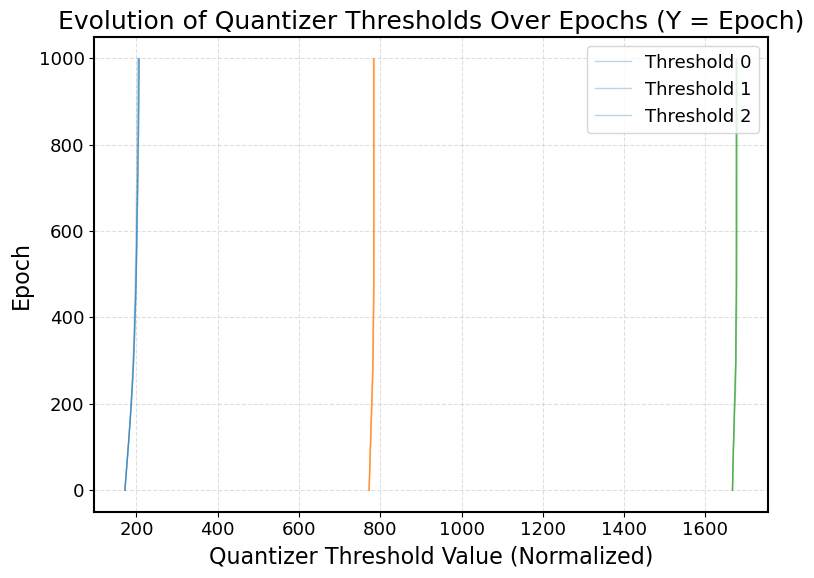

In [66]:
df_filtered = df_sorted[df_sorted["fingerprint"].isin(last_rows["fingerprint"])]

plt.figure(figsize=(8, 6))

for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        plt.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.3,
            linewidth=1.0,
        )

plt.xlabel("Quantizer Threshold Value (Normalized)")
plt.ylabel("Epoch")
plt.title("Evolution of Quantizer Thresholds Over Epochs (Y = Epoch)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend([f"Threshold {i}" for i in range(len(threshold_cols))], loc="best")
plt.tight_layout()
plt.show()


In [67]:
# --- Step 1: filter once, and keep this reference ---
df_filtered = df_sorted[df_sorted["fingerprint"].isin(last_rows["fingerprint"])].copy()

# --- Step 2: add charge thresholds to this same object ---
for i in range(3):
    df_filtered.loc[:, f"charge_threshold_{i}"] = df_filtered.apply(
        lambda row: unnormalize_thresholds(
            [row[f"quantizer_threshold_{i}"]],
            mu=test_generator.dataset_mean[0],
            sigma=test_generator.dataset_std[0],
            s_pos=test_generator.norm_factor_pos,
            s_neg=test_generator.norm_factor_neg,
        )[0],
        axis=1,
    )

/tmp/ipykernel_2157/2859343362.py:5: RuntimeWarning: overflow encountered in power
  raw_charges = np.sign(log_vals) * (2 ** np.abs(log_vals) - 1)
/tmp/ipykernel_2157/2859343362.py:5: RuntimeWarning: overflow encountered in power
  raw_charges = np.sign(log_vals) * (2 ** np.abs(log_vals) - 1)
/tmp/ipykernel_2157/2859343362.py:5: RuntimeWarning: overflow encountered in power
  raw_charges = np.sign(log_vals) * (2 ** np.abs(log_vals) - 1)


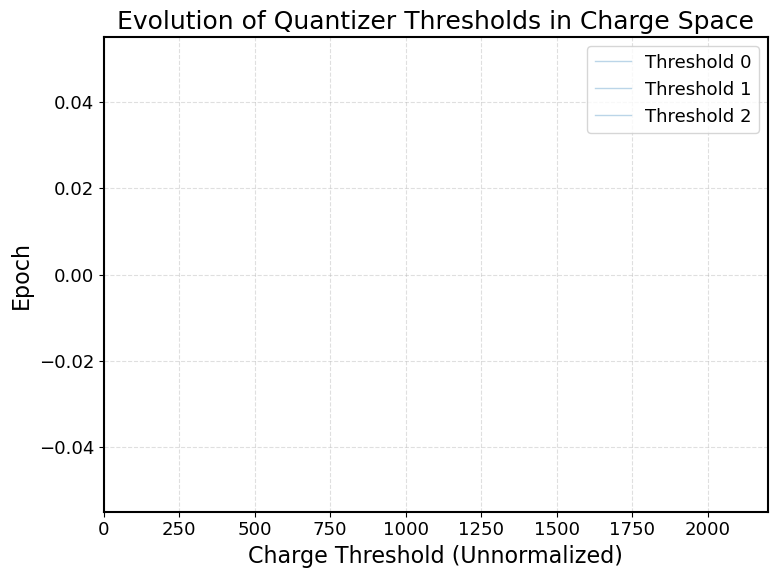

In [68]:
# --- Step 3: plot ---
threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]

plt.figure(figsize=(8, 6))
for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        plt.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.3,
            linewidth=1.0,
        )

plt.xlabel("Charge Threshold (Unnormalized)")
plt.ylabel("Epoch")
plt.title("Evolution of Quantizer Thresholds in Charge Space")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend([f"Threshold {i}" for i in range(3)], loc="best")
plt.tight_layout()
plt.xlim([0, 2200])
plt.show()

In [69]:
plt.rcParams.update({
    "font.size": 14,           # base font size
    "axes.labelsize": 16,      # axis label font
    "axes.titlesize": 18,      # title font
    "xtick.labelsize": 13,     # x-tick labels
    "ytick.labelsize": 13,     # y-tick labels
    "legend.fontsize": 13,     # legend text
    "axes.linewidth": 1.5,     # axis thickness
    "lines.linewidth": 2.0,    # curve thickness
    "grid.alpha": 0.5,         # grid visibility
})

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from scipy.stats import norm

# --- Assume df_filtered already has charge_threshold_0..2 computed ---
threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]  # blue/orange/green

# --- Collect final thresholds per run (last epoch only) ---
last_rows = (
    df_filtered.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)

raw_th0 = last_rows["charge_threshold_0"].to_numpy()
raw_th1 = last_rows["charge_threshold_1"].to_numpy()
raw_th2 = last_rows["charge_threshold_2"].to_numpy()

# --- Compute histogram bins ---
all_raw = np.concatenate([raw_th0, raw_th1, raw_th2])
bins = np.histogram_bin_edges(all_raw, bins=30)

# --- Layout with shared x-axis ---
fig, (ax_evol, ax_hist) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)

# ================================================================
# (1) EVOLUTION PLOT
# ================================================================
i = 0
for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        ax_evol.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.3,
            linewidth=1.0,
        )

ax_evol.set_ylabel("Epoch")
# ax_evol.set_title("Evolution of Charge Thresholds + Distribution Summary")
ax_evol.grid(True, linestyle="--", alpha=0.4)
ax_evol.invert_yaxis()

handles = [
    mlines.Line2D([], [], color='C0', lw=2, label='Threshold 0'),
    mlines.Line2D([], [], color='C1', lw=2, label='Threshold 1'),
    mlines.Line2D([], [], color='C2', lw=2, label='Threshold 2')
]

ax_evol.legend(handles=handles, loc="lower left", frameon=True)


# ================================================================
# (2) HISTOGRAM (aligned to same x-axis)
# ================================================================
mu0, sigma0 = np.mean(raw_th0), np.std(raw_th0)
mu1, sigma1 = np.mean(raw_th1), np.std(raw_th1)
mu2, sigma2 = np.mean(raw_th2), np.std(raw_th2)

label0 = rf"Th0: $\mu={mu0:.1f},\;\sigma={sigma0:.1f}$"
label1 = rf"Th1: $\mu={mu1:.1f},\;\sigma={sigma1:.1f}$"
label2 = rf"Th2: $\mu={mu2:.1f},\;\sigma={sigma2:.1f}$"

ax_hist.hist(raw_th0, bins=bins, alpha=0.5, color=colors[0],
              label=label0, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th1, bins=bins, alpha=0.5, color=colors[1],
              label=label1, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th2, bins=bins, alpha=0.5, color=colors[2],
              label=label2, histtype='stepfilled', edgecolor='black')

# --- Overlay noise PDF ---
x_pdf = np.linspace(0, max(bins), 1000)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf * len(all_raw) * (bins[1] - bins[0])

ax_hist.plot(
    x_pdf, pdf_scaled,
    'k--', linewidth=1.5,
    label=rf"Noise: $N({mu_noise:.1f}, {sigma_noise:.1f})\,e^-$"
)

# --- Shaded 1σ region under noise PDF ---
in_band = (x_pdf >= mu_noise - sigma_noise) & (x_pdf <= mu_noise + sigma_noise)
ax_hist.fill_between(
    x_pdf, 0, pdf_scaled,
    where=in_band, color='red', alpha=0.2,
    label=rf"$1\sigma={sigma_noise:.0f}\,e^-$ Noise Band"
)

# --- Vertical lines marking ±1σ ---
pdf_val = norm.pdf(mu_noise + sigma_noise, loc=mu_noise, scale=sigma_noise)
pdf_val_scaled = pdf_val * len(all_raw) * (bins[1] - bins[0])
ax_hist.vlines(
    [mu_noise - sigma_noise, mu_noise + sigma_noise],
    0, pdf_val_scaled,
    color='red', linestyle='-.', linewidth=1.5
)

ax_hist.set_xlabel("Charge (electrons)")
ax_hist.set_ylabel("Counts")
ax_hist.grid(True, linestyle="--", alpha=0.4)
ax_hist.legend(loc="upper right")

plt.xlim([0, 2200])
plt.tight_layout()
plt.show()


ValueError: autodetected range of [inf, inf] is not finite

In [71]:
# --- DROP-IN: same plot, just add iMinuit fits for legend labels ---

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import norm
from iminuit import Minuit

# ───────────────────────────────────────────────────────────────────
# CHANGE: add unbinned Gaussian MLE with iMinuit to get μ, σ and errors
# REASON: show μ±Δμ and σ±Δσ in legend (requested)
def gaussian_nll(x, mu, sigma):
    if sigma <= 0:
        return np.inf
    return 0.5 * np.sum(np.log(2.0 * np.pi * sigma**2) + ((x - mu) / sigma) ** 2)

def fit_gaussian_thresholds(values, label="Th"):
    x = np.asarray(values, dtype=np.float64)
    mu0, sigma0 = x.mean(), x.std(ddof=0)
    m = Minuit(lambda mu, sigma: gaussian_nll(x, mu, sigma), mu=mu0, sigma=sigma0)
    m.errordef = Minuit.LIKELIHOOD      # correct for NLL
    m.limits["sigma"] = (1e-12, None)   # keep σ > 0
    m.migrad(); m.hesse()
    mu, sigma = m.values["mu"], m.values["sigma"]
    dmu, dsigma = m.errors["mu"], m.errors["sigma"]
    return mu, sigma, dmu, dsigma
# ───────────────────────────────────────────────────────────────────

# --- Assume df_filtered already has charge_threshold_0..2 computed ---
threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]  # blue/orange/green

# --- Collect final thresholds per run (last epoch only) ---
last_rows = (
    df_filtered.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)

raw_th0 = last_rows["charge_threshold_0"].to_numpy()
raw_th1 = last_rows["charge_threshold_1"].to_numpy()
raw_th2 = last_rows["charge_threshold_2"].to_numpy()

# --- Compute histogram bins ---
all_raw = np.concatenate([raw_th0, raw_th1, raw_th2])
bins = np.histogram_bin_edges(all_raw, bins=30)

# --- Layout with shared x-axis ---
fig, (ax_evol, ax_hist) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)

# ================================================================
# (1) EVOLUTION PLOT
# ================================================================
for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        ax_evol.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.3,
            linewidth=1.0,
        )

ax_evol.set_ylabel("Epoch")
ax_evol.grid(True, linestyle="--", alpha=0.4)
ax_evol.invert_yaxis()

handles = [
    mlines.Line2D([], [], color='C0', lw=2, label='Threshold 0'),
    mlines.Line2D([], [], color='C1', lw=2, label='Threshold 1'),
    mlines.Line2D([], [], color='C2', lw=2, label='Threshold 2')
]
ax_evol.legend(handles=handles, loc="lower left", frameon=True)

# ================================================================
# (2) HISTOGRAM (aligned to same x-axis)
# ================================================================
# CHANGE: replace mean/std with iMinuit fits and include uncertainties
# REASON: you asked to show μ±Δμ and σ±Δσ in the labels
mu0, sigma0, dmu0, dsigma0 = fit_gaussian_thresholds(raw_th0, "Th0")
mu1, sigma1, dmu1, dsigma1 = fit_gaussian_thresholds(raw_th1, "Th1")
mu2, sigma2, dmu2, dsigma2 = fit_gaussian_thresholds(raw_th2, "Th2")

label0 = rf"Th0: $\mu=\mathbf{{{mu0:.1f}}}\pm{dmu0:.1f},\;\sigma={sigma0:.1f}\pm{dsigma0:.1f}$"
label1 = rf"Th1: $\mu=\mathbf{{{mu1:.1f}}}\pm{dmu1:.1f},\;\sigma={sigma1:.1f}\pm{dsigma1:.1f}$"
label2 = rf"Th2: $\mu=\mathbf{{{mu2:.1f}}}\pm{dmu2:.1f},\;\sigma={sigma2:.1f}\pm{dsigma2:.1f}$"

ax_hist.hist(raw_th0, bins=bins, alpha=0.5, color=colors[0],
              label=label0, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th1, bins=bins, alpha=0.5, color=colors[1],
              label=label1, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th2, bins=bins, alpha=0.5, color=colors[2],
              label=label2, histtype='stepfilled', edgecolor='black')

# --- Overlay noise PDF ---
x_pdf = np.linspace(0, max(bins), 1000)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf * len(all_raw) * (bins[1] - bins[0])

ax_hist.plot(
    x_pdf, pdf_scaled,
    'k--', linewidth=1.5,
    label=rf"Noise: $N({mu_noise:.1f}, {sigma_noise:.1f})\,e^-$"
)

# --- Shaded 1σ region under noise PDF ---
in_band = (x_pdf >= mu_noise - sigma_noise) & (x_pdf <= mu_noise + sigma_noise)
ax_hist.fill_between(
    x_pdf, 0, pdf_scaled,
    where=in_band, color='red', alpha=0.2,
    label=rf"$1\sigma={sigma_noise:.0f}\,e^-$ Noise Band"
)

# --- Vertical lines marking ±1σ ---
pdf_val = norm.pdf(mu_noise + sigma_noise, loc=mu_noise, scale=sigma_noise)
pdf_val_scaled = pdf_val * len(all_raw) * (bins[1] - bins[0])
ax_hist.vlines(
    [mu_noise - sigma_noise, mu_noise + sigma_noise],
    0, pdf_val_scaled,
    color='red', linestyle='-.', linewidth=1.5
)

ax_hist.set_xlabel("Charge (electrons)")
ax_hist.set_ylabel("Counts")
ax_hist.grid(True, linestyle="--", alpha=0.4)
ax_hist.legend(loc="upper right")
ax_hist.set_ylim(0, 45)

plt.xlim([0, 2400])
plt.tight_layout()
plt.show()


ValueError: autodetected range of [inf, inf] is not finite

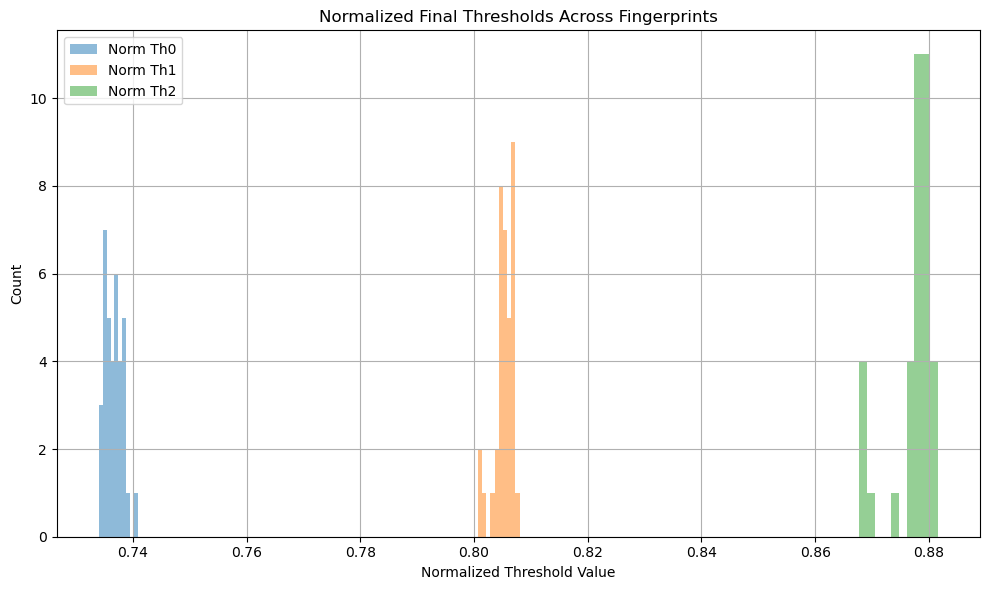

In [71]:
plt.figure(figsize=(10, 6))
plt.hist(last_rows["quantizer_threshold_0"], bins=10, alpha=0.5, label="Norm Th0")
plt.hist(last_rows["quantizer_threshold_1"], bins=10, alpha=0.5, label="Norm Th1")
plt.hist(last_rows["quantizer_threshold_2"], bins=10, alpha=0.5, label="Norm Th2")
plt.title("Normalized Final Thresholds Across Fingerprints")
plt.xlabel("Normalized Threshold Value")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [72]:
raw_th0, raw_th1, raw_th2 = [], [], []

for _, row in last_rows.iterrows():
    norm_vec = [
        row["quantizer_threshold_0"],
        row["quantizer_threshold_1"],
        row["quantizer_threshold_2"],
    ]
    charge_vec = norm_vec
    raw_th0.append(charge_vec[0])
    raw_th1.append(charge_vec[1])
    raw_th2.append(charge_vec[2])


In [73]:
from scipy.stats import norm


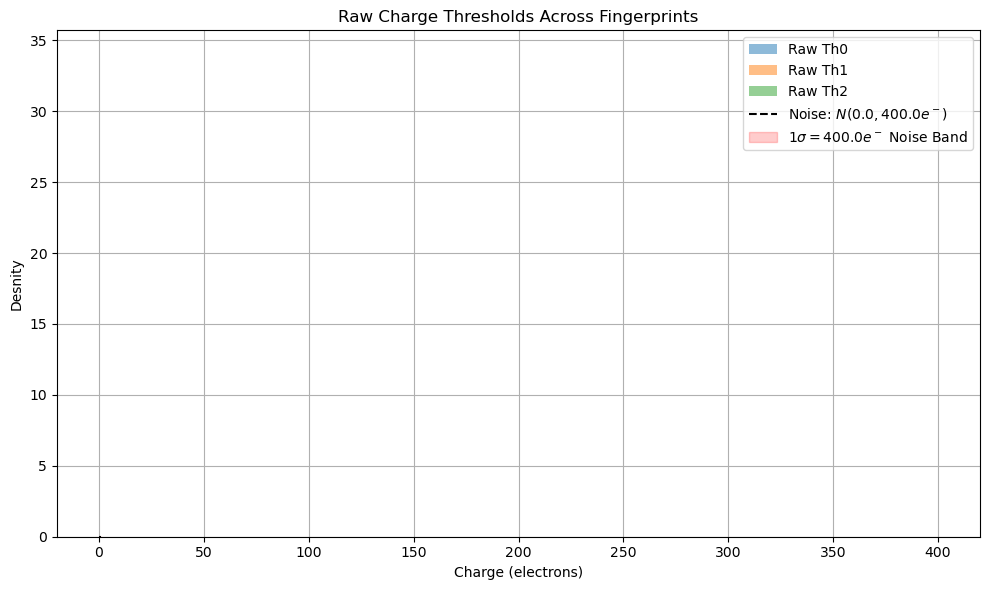

In [74]:
all_raw = np.concatenate([raw_th0, raw_th1, raw_th2])
bins = np.histogram_bin_edges(all_raw, bins=30)  # auto-computed range

plt.figure(figsize=(10, 6))
plt.hist(raw_th0, bins=bins, alpha=0.5, label="Raw Th0")
plt.hist(raw_th1, bins=bins, alpha=0.5, label="Raw Th1")
plt.hist(raw_th2, bins=bins, alpha=0.5, label="Raw Th2")

mu_noise = NOISE_MU
sigma_noise = NOISE_SIGMA

# X-range for PDF
x_pdf = np.linspace(0, max(bins), 1000)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf * len(all_raw) * (bins[1] - bins[0])  # Scale to match histogram

plt.plot(x_pdf, pdf_scaled, 'k--', linewidth=1.5, label=rf"Noise: $N({mu_noise}, {sigma_noise}e^-$)")

# Shaded region under the PDF between 0–400e⁻
in_band = (x_pdf >= 0) & (x_pdf <= sigma_noise)
plt.fill_between(x_pdf, 0, pdf_scaled, where=in_band, alpha=0.2, 
                 color='red', label=rf"$1\sigma={sigma_noise}e^-$ Noise Band")

# Shaded 1σ region
pdf_val = norm.pdf(sigma_noise, loc=mu_noise, scale=sigma_noise)
pdf_val_scaled = pdf_val * len(all_raw) * (bins[1] - bins[0])
plt.vlines(
    sigma_noise, 0, pdf_val_scaled,
    color='red', linestyle='-.', linewidth=1.5)

plt.title("Raw Charge Thresholds Across Fingerprints")
plt.xlabel("Charge (electrons)")
plt.ylabel("Desnity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


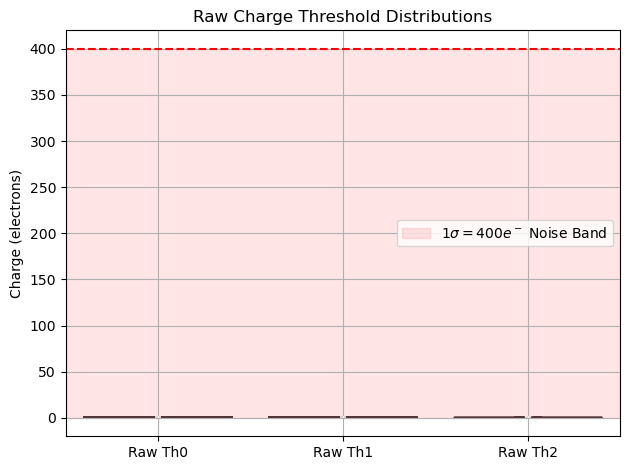

In [75]:
import seaborn as sns

sns.violinplot(data=[raw_th0, raw_th1, raw_th2])
plt.axhspan(0, sigma_noise, color='red', alpha=0.1, label=r"$1\sigma=400e^-$ Noise Band")
plt.axhline(sigma_noise, color='red', linestyle='--', linewidth=1.5)

plt.xticks([0,1,2], ["Raw Th0", "Raw Th1", "Raw Th2"])
plt.title("Raw Charge Threshold Distributions")
plt.ylabel("Charge (electrons)")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


In [18]:
from iminuit import Minuit

# ── Log-likelihood for a Normal(μ, σ²) ─────────────────────────────
def gaussian_nll(x, mu, sigma):
    """Unbinned NLL for a Gaussian model."""
    if sigma <= 0:
        return np.inf          # keep optimisation in physical region
    return 0.5 * np.sum(np.log(2.0 * np.pi * sigma**2) +
                        ((x - mu) / sigma) ** 2)

# ── Fit helper for any threshold array ─────────────────────────────
def fit_gaussian_thresholds(values, label, color=None):
    """
    Fit a Gaussian to 'values' with iminuit and print μ±Δμ, σ±Δσ.
    Optionally returns (μ, σ, Δμ, Δσ) for further use.
    """
    x = np.asarray(values, dtype=np.float64)

    # Initial guesses via method-of-moments
    mu0, sigma0 = x.mean(), x.std(ddof=0)

    # Minuit fit
    m = Minuit(lambda mu, sigma: gaussian_nll(x, mu, sigma),
               mu=mu0, sigma=sigma0)
    m.errordef = Minuit.LIKELIHOOD
    m.limits["sigma"] = (1e-9, None)   # constrain σ > 0
    m.migrad(); m.hesse()
    mu, sigma = m.values["mu"], m.values["sigma"]
    dmu, dsigma = m.errors["mu"], m.errors["sigma"]

    print(f"{label}: μ = {mu:.2f} ± {dmu:.2f}, "
          f"σ = {sigma:.2f} ± {dsigma:.2f}")

    return mu, sigma, dmu, dsigma
    
fit_gaussian_thresholds(raw_th0, "Th0")
fit_gaussian_thresholds(raw_th1, "Th1")
fit_gaussian_thresholds(raw_th2, "Th2")


Th0: μ = 597.81 ± 2.84, σ = 7.51 ± 2.01
Th1: μ = 1094.33 ± 1.82, σ = 4.83 ± 1.29
Th2: μ = 2038.79 ± 0.91, σ = 2.42 ± 0.64


(2038.7901000000002, 2.416381568733351, 0.913306514763248, 0.6446869488748931)

Th0: μ = 597.81 ± 2.84, σ = 7.51 ± 2.01
Th1: μ = 1094.33 ± 1.82, σ = 4.83 ± 1.29
Th2: μ = 2038.79 ± 0.91, σ = 2.42 ± 0.64


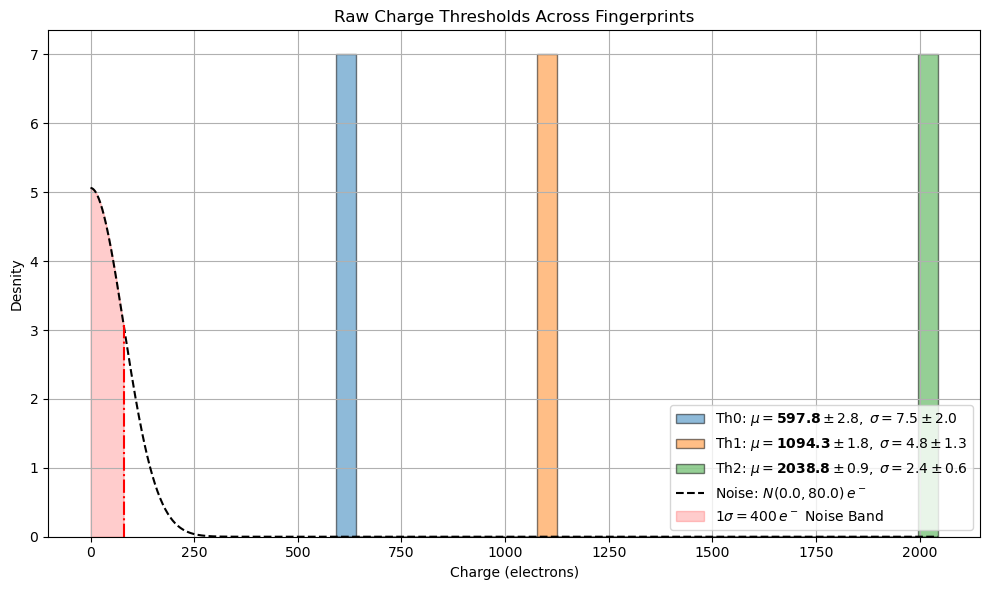

In [19]:
all_raw = np.concatenate([raw_th0, raw_th1, raw_th2])
bins = np.histogram_bin_edges(all_raw, bins=30)  # auto-computed range


mu0, sigma0, dmu0, dsigma0 = fit_gaussian_thresholds(raw_th0, "Th0")
mu1, sigma1, dmu1, dsigma1 = fit_gaussian_thresholds(raw_th1, "Th1")
mu2, sigma2, dmu2, dsigma2 = fit_gaussian_thresholds(raw_th2, "Th2")


plt.figure(figsize=(10, 6))
label0 = rf"Th0: $\mu=\mathbf{{{mu0:.1f}}}\pm{dmu0:.1f},\;\sigma={sigma0:.1f}\pm{dsigma0:.1f}$"
label1 = rf"Th1: $\mu=\mathbf{{{mu1:.1f}}}\pm{dmu1:.1f},\;\sigma={sigma1:.1f}\pm{dsigma1:.1f}$"
label2 = rf"Th2: $\mu=\mathbf{{{mu2:.1f}}}\pm{dmu2:.1f},\;\sigma={sigma2:.1f}\pm{dsigma2:.1f}$"

plt.hist(raw_th0, bins=bins, alpha=0.5, label=label0, edgecolor='black', histtype='stepfilled')
plt.hist(raw_th1, bins=bins, alpha=0.5, label=label1, edgecolor='black', histtype='stepfilled')
plt.hist(raw_th2, bins=bins, alpha=0.5, label=label2, edgecolor='black', histtype='stepfilled')

mu_noise = NOISE_MU
sigma_noise = NOISE_SIGMA

# X-range for PDF
x_pdf = np.linspace(0, max(bins), 1000)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf * len(all_raw) * (bins[1] - bins[0])  # Scale to match histogram

plt.plot(x_pdf, pdf_scaled, 'k--', linewidth=1.5, 
         label=rf"Noise: $N({mu_noise:.1f}, {sigma_noise:.1f})\,e^-$")

# Shaded region under the PDF between 0–400e⁻
in_band = (x_pdf >= 0) & (x_pdf <= sigma_noise)
plt.fill_between(x_pdf, 0, pdf_scaled, where=in_band, alpha=0.2, 
                 color='red', label=r"$1\sigma=400\,e^-$ Noise Band")

# Shaded 1σ region
pdf_val = norm.pdf(sigma_noise, loc=mu_noise, scale=sigma_noise)
pdf_val_scaled = pdf_val * len(all_raw) * (bins[1] - bins[0])
plt.vlines(
    sigma_noise, 0, pdf_val_scaled,
    color='red', linestyle='-.', linewidth=1.5)

plt.title("Raw Charge Thresholds Across Fingerprints")
plt.xlabel("Charge (electrons)")
plt.ylabel("Desnity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Th0: μ = 597.81 ± 2.84, σ = 7.51 ± 2.01


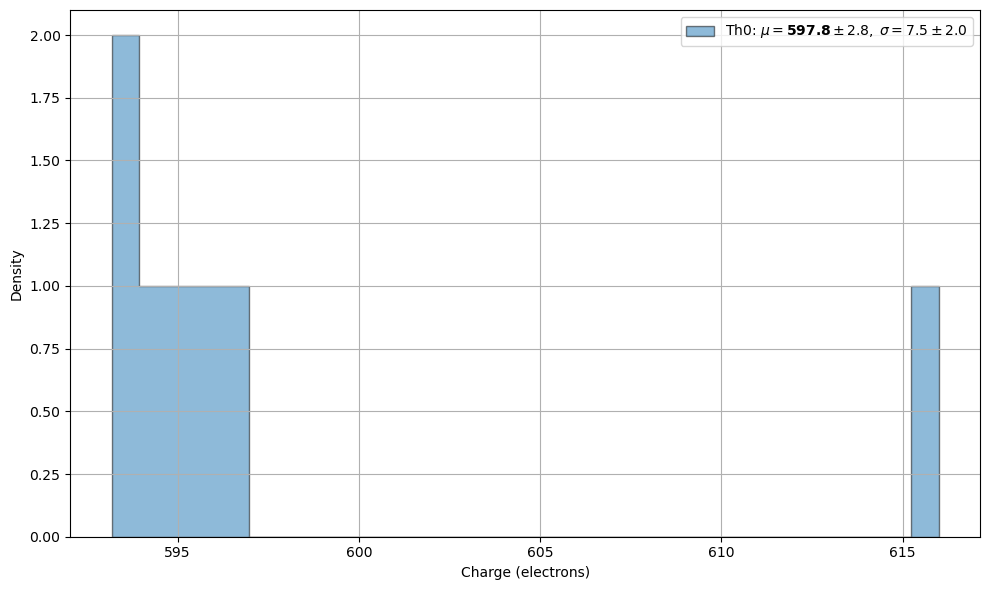

Th1: μ = 1094.33 ± 1.82, σ = 4.83 ± 1.29


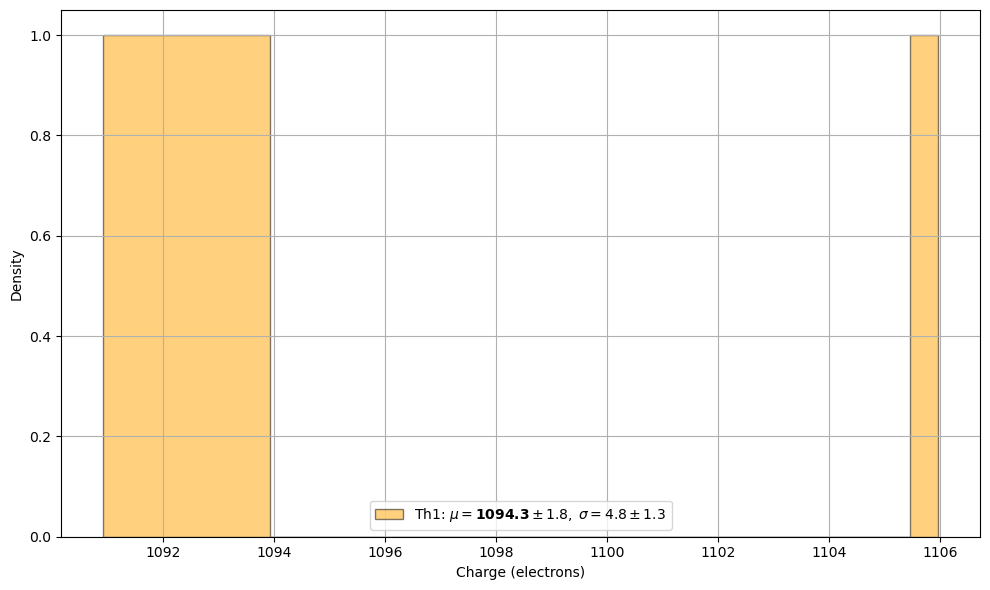

Th2: μ = 2038.79 ± 0.91, σ = 2.42 ± 0.64


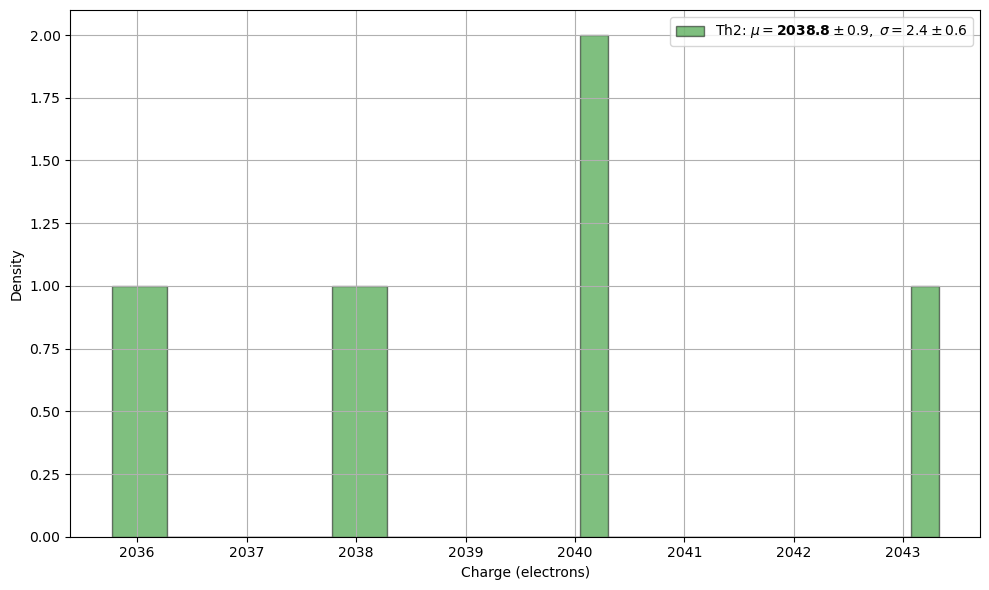

In [20]:
# Threshold 0
bins0 = np.histogram_bin_edges(raw_th0, bins=30)
mu0, sigma0, dmu0, dsigma0 = fit_gaussian_thresholds(raw_th0, "Th0")
plt.figure(figsize=(10, 6))
label0 = rf"Th0: $\mu=\mathbf{{{mu0:.1f}}}\pm{dmu0:.1f},\;\sigma={sigma0:.1f}\pm{dsigma0:.1f}$"
plt.hist(raw_th0, bins=bins0, alpha=0.5, label=label0, edgecolor='black', histtype='stepfilled')
plt.xlabel("Charge (electrons)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Threshold 1
bins1 = np.histogram_bin_edges(raw_th1, bins=30)
mu1, sigma1, dmu1, dsigma1 = fit_gaussian_thresholds(raw_th1, "Th1")
plt.figure(figsize=(10, 6))
label1 = rf"Th1: $\mu=\mathbf{{{mu1:.1f}}}\pm{dmu1:.1f},\;\sigma={sigma1:.1f}\pm{dsigma1:.1f}$"
plt.hist(raw_th1, bins=bins1, alpha=0.5, label=label1, color='orange', edgecolor='black', histtype='stepfilled')
plt.xlabel("Charge (electrons)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Threshold 2
bins2 = np.histogram_bin_edges(raw_th2, bins=30)
mu2, sigma2, dmu2, dsigma2 = fit_gaussian_thresholds(raw_th2, "Th2")
plt.figure(figsize=(10, 6))
label2 = rf"Th2: $\mu=\mathbf{{{mu2:.1f}}}\pm{dmu2:.1f},\;\sigma={sigma2:.1f}\pm{dsigma2:.1f}$"
plt.hist(raw_th2, bins=bins2, alpha=0.5, label=label2, color='green', edgecolor='black', histtype='stepfilled')
plt.xlabel("Charge (electrons)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
from iminuit import Minuit
import numpy as np

def gaussian_nll(x, mu, sigma):
    """Unbinned negative log-likelihood for a Gaussian."""
    if sigma <= 0:
        return np.inf
    return 0.5 * np.sum(np.log(2.0 * np.pi * sigma**2) +
                        ((x - mu) / sigma) ** 2)

def fit_gaussian_thresholds(values, label, color=None):
    """
    Fit a Gaussian to 'values' with MINOS asymmetric errors using iminuit 2.x.
    Returns: mu, sigma, dmu_lo, dmu_hi, dsig_lo, dsig_hi
    """
    x = np.asarray(values, dtype=np.float64)
    # Initial guesses
    mu0, sigma0 = x.mean(), x.std(ddof=0)

    # Minuit setup
    m = Minuit(lambda mu, sigma: gaussian_nll(x, mu, sigma),
               mu=mu0, sigma=sigma0)
    m.errordef = Minuit.LIKELIHOOD
    m.limits["sigma"] = (1e-9, None)

    # Run the fit
    m.migrad()
    m.hesse()          # compute symmetric errors & correlation
    m.minos("mu", "sigma")  # compute asymmetric errors

    # Best-fit values
    mu    = m.values["mu"]
    sigma = m.values["sigma"]

    # Asymmetric errors from .merrors
    dmu_lo  = abs(m.merrors["mu"].lower)
    dmu_hi  = abs(m.merrors["mu"].upper)
    dsig_lo = abs(m.merrors["sigma"].lower)
    dsig_hi = abs(m.merrors["sigma"].upper)

    print(f"{label}:")
    print(f"  μ = {mu:.3f}   -{dmu_lo:.3f} / +{dmu_hi:.3f}")
    print(f"  σ = {sigma:.3f}   -{dsig_lo:.3f} / +{dsig_hi:.3f}")

    return mu, sigma, dmu_lo, dmu_hi, dsig_lo, dsig_hi

# Example calls:
fit_gaussian_thresholds(raw_th0, "Th0")
fit_gaussian_thresholds(raw_th1, "Th1")
fit_gaussian_thresholds(raw_th2, "Th2")


Th0:
  μ = 599.319   -5.135 / +5.135
  σ = 9.636   -2.613 / +4.748
Th1:
  μ = 1095.317   -3.296 / +3.296
  σ = 6.184   -1.677 / +3.047
Th2:
  μ = 2038.841   -1.643 / +1.643
  σ = 3.083   -0.836 / +1.519


(2038.8405,
 3.0833640646216183,
 1.6432491172756407,
 1.643249117042197,
 0.8362098781430016,
 1.5192927525697346)

In [30]:
def format_err(val, err_lo, err_hi, ndigits=1, bold=False):
    """Format parameter with symmetric or asymmetric errors in LaTeX."""
    lo = round(err_lo, ndigits)
    hi = round(err_hi, ndigits)

    val_str = rf"\mathbf{{{val:.{ndigits}f}}}" if bold else f"{val:.{ndigits}f}"

    if lo == hi:  # symmetric
        return rf"{val_str} \pm {lo:.{ndigits}f}"
    else:         # asymmetric
        return rf"{val_str}^{{+{hi:.{ndigits}f}}}_{{-{lo:.{ndigits}f}}}"


In [31]:
plt.rcParams.update({
    "font.size": 14,       # default text size
    "axes.titlesize": 16,  # title
    "axes.labelsize": 14,  # x and y labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

Th0:
  μ = 599.319   -5.135 / +5.135
  σ = 9.636   -2.613 / +4.748
Th1:
  μ = 1095.317   -3.296 / +3.296
  σ = 6.184   -1.677 / +3.047
Th2:
  μ = 2038.841   -1.643 / +1.643
  σ = 3.083   -0.836 / +1.519


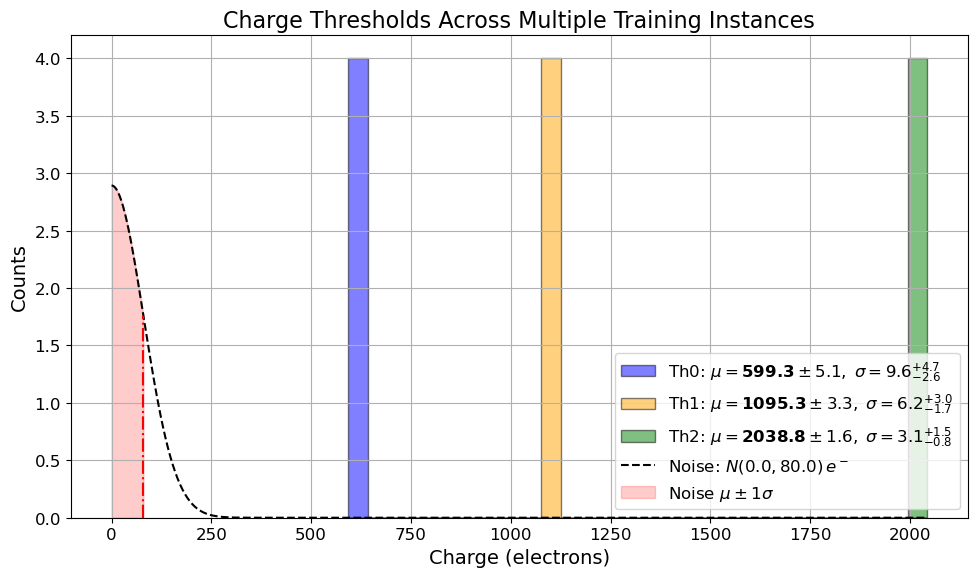

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Collect all raw data for common bin edges
all_raw = np.concatenate([raw_th0, raw_th1, raw_th2])
bins = np.histogram_bin_edges(all_raw, bins=30)

# Fit Gaussian thresholds (with MINOS asymmetric errors)
mu0, sigma0, dmu0_lo, dmu0_hi, dsig0_lo, dsig0_hi = fit_gaussian_thresholds(raw_th0, "Th0")
mu1, sigma1, dmu1_lo, dmu1_hi, dsig1_lo, dsig1_hi = fit_gaussian_thresholds(raw_th1, "Th1")
mu2, sigma2, dmu2_lo, dmu2_hi, dsig2_lo, dsig2_hi = fit_gaussian_thresholds(raw_th2, "Th2")

colors = ["blue", "orange", "green"]

plt.figure(figsize=(10, 6))

# --- Helper to plot one threshold ---
def plot_threshold(data, bins, mu, sigma, dmu_lo, dmu_hi, dsig_lo, dsig_hi, label, color):
    # Histogram
    plt.hist(data, bins=bins, alpha=0.5, color=color, edgecolor='black',
             histtype='stepfilled', label=label)

# --- Labels with asymmetric errors ---
mu_str0    = format_err(mu0, dmu0_lo, dmu0_hi, ndigits=1, bold=True)
sigma_str0 = format_err(sigma0, dsig0_lo, dsig0_hi, ndigits=1)
label0 = rf"Th0: $\mu={mu_str0},\;\sigma={sigma_str0}$"

mu_str1    = format_err(mu1, dmu1_lo, dmu1_hi, ndigits=1, bold=True)
sigma_str1 = format_err(sigma1, dsig1_lo, dsig1_hi, ndigits=1)
label1 = rf"Th1: $\mu={mu_str1},\;\sigma={sigma_str1}$"

mu_str2    = format_err(mu2, dmu2_lo, dmu2_hi, ndigits=1, bold=True)
sigma_str2 = format_err(sigma2, dsig2_lo, dsig2_hi, ndigits=1)
label2 = rf"Th2: $\mu={mu_str2},\;\sigma={sigma_str2}$"

# Plot thresholds
plot_threshold(raw_th0, bins, mu0, sigma0, dmu0_lo, dmu0_hi, dsig0_lo, dsig0_hi, label0, colors[0])
plot_threshold(raw_th1, bins, mu1, sigma1, dmu1_lo, dmu1_hi, dsig1_lo, dsig1_hi, label1, colors[1])
plot_threshold(raw_th2, bins, mu2, sigma2, dmu2_lo, dmu2_hi, dsig2_lo, dsig2_hi, label2, colors[2])

# --- Noise reference distribution ---
mu_noise = NOISE_MU
sigma_noise = NOISE_SIGMA
x_pdf = np.linspace(0, max(bins), 1000)
pdf_noise = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_noise *= len(all_raw) * (bins[1] - bins[0])
plt.plot(x_pdf, pdf_noise, 'k--', linewidth=1.5,
         label=rf"Noise: $N({mu_noise:.1f}, {sigma_noise:.1f})\,e^-$")

# Optional shading for noise 1σ band
in_band = (x_pdf >= mu_noise - sigma_noise) & (x_pdf <= mu_noise + sigma_noise)
plt.fill_between(x_pdf, 0, pdf_noise, where=in_band, alpha=0.2, color='red',
                 label=r"Noise $\mu\pm1\sigma$")
plt.vlines(
    sigma_noise, 0, pdf_val_scaled,
    color='red', linestyle='-.', linewidth=1.5)

# Formatting
plt.title("Charge Thresholds Across Multiple Training Instances")
plt.xlabel("Charge (electrons)")
plt.ylabel("Counts")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Th0:
  μ = 599.319   -5.135 / +5.135
  σ = 9.636   -2.613 / +4.748
Th1:
  μ = 1095.317   -3.296 / +3.296
  σ = 6.184   -1.677 / +3.047
Th2:
  μ = 2038.841   -1.643 / +1.643
  σ = 3.083   -0.836 / +1.519


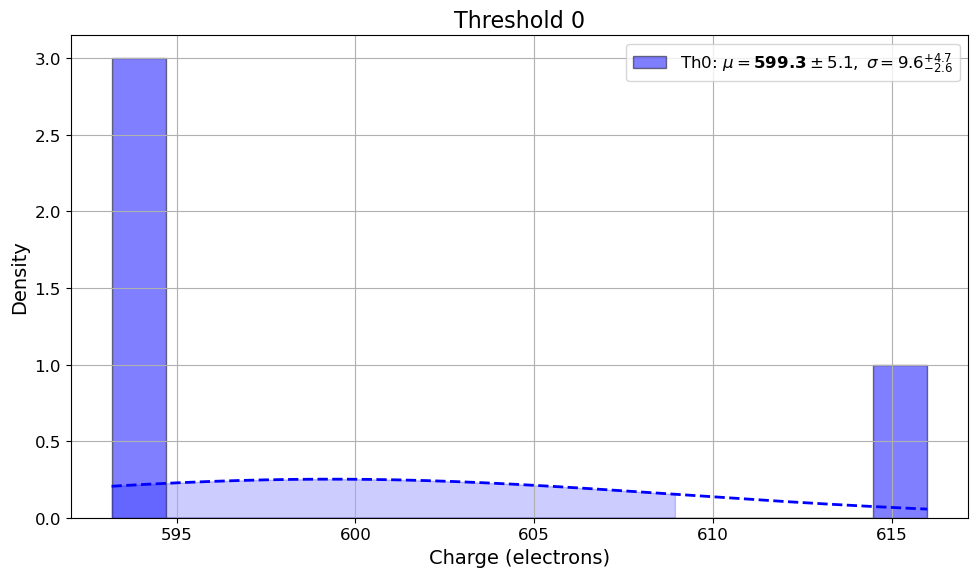

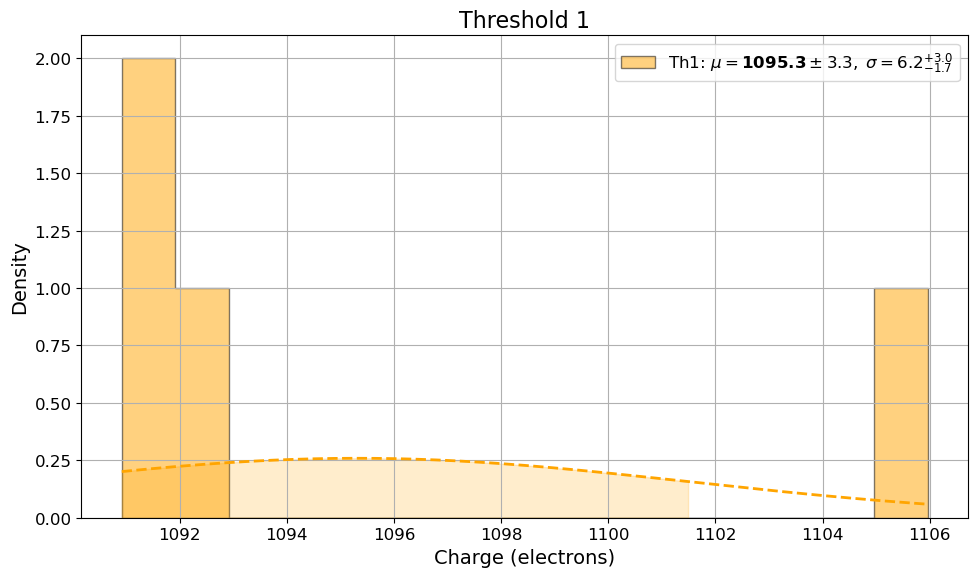

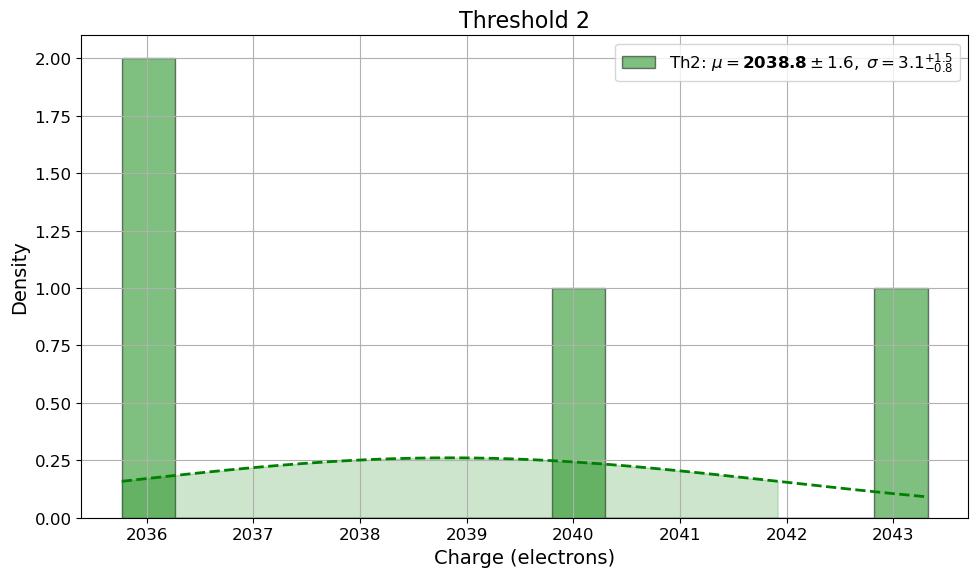

In [33]:
# Fit Gaussian thresholds (with MINOS asymmetric errors)
mu0, sigma0, dmu0_lo, dmu0_hi, dsig0_lo, dsig0_hi = fit_gaussian_thresholds(raw_th0, "Th0")
mu1, sigma1, dmu1_lo, dmu1_hi, dsig1_lo, dsig1_hi = fit_gaussian_thresholds(raw_th1, "Th1")
mu2, sigma2, dmu2_lo, dmu2_hi, dsig2_lo, dsig2_hi = fit_gaussian_thresholds(raw_th2, "Th2")

colors = ["blue", "orange", "green"]

# --- Helper to plot one threshold ---
def plot_threshold(data, bins, mu, sigma, dmu_lo, dmu_hi, dsig_lo, dsig_hi, label, color, title):
    plt.figure(figsize=(10, 6))
    bins = np.histogram_bin_edges(data, bins=bins)
    # Histogram
    plt.hist(data, bins=bins, alpha=0.5, color=color, edgecolor='black',
             histtype='stepfilled', label=label)

    # Gaussian fit curve
    x_fit = np.linspace(bins[0], bins[-1], 1000)
    pdf = norm.pdf(x_fit, mu, sigma) * len(data) * (bins[1] - bins[0])
    plt.plot(x_fit, pdf, color=color, linestyle='--', linewidth=2)

    # ±1σ shaded region
    in_band = (x_fit >= mu - sigma) & (x_fit <= mu + sigma)
    plt.fill_between(x_fit, 0, pdf, where=in_band, color=color, alpha=0.2)

    # Formatting
    plt.title(title)
    plt.xlabel("Charge (electrons)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Labels with asymmetric errors ---
mu_str0    = format_err(mu0, dmu0_lo, dmu0_hi, ndigits=1, bold=True)
sigma_str0 = format_err(sigma0, dsig0_lo, dsig0_hi, ndigits=1)
label0 = rf"Th0: $\mu={mu_str0},\;\sigma={sigma_str0}$"

mu_str1    = format_err(mu1, dmu1_lo, dmu1_hi, ndigits=1, bold=True)
sigma_str1 = format_err(sigma1, dsig1_lo, dsig1_hi, ndigits=1)
label1 = rf"Th1: $\mu={mu_str1},\;\sigma={sigma_str1}$"

mu_str2    = format_err(mu2, dmu2_lo, dmu2_hi, ndigits=1, bold=True)
sigma_str2 = format_err(sigma2, dsig2_lo, dsig2_hi, ndigits=1)
label2 = rf"Th2: $\mu={mu_str2},\;\sigma={sigma_str2}$"

bins = 15
# Plot each threshold in its own figure
plot_threshold(raw_th0, bins, mu0, sigma0, dmu0_lo, dmu0_hi, dsig0_lo, dsig0_hi, label0, colors[0], "Threshold 0")
plot_threshold(raw_th1, bins, mu1, sigma1, dmu1_lo, dmu1_hi, dsig1_lo, dsig1_hi, label1, colors[1], "Threshold 1")
plot_threshold(raw_th2, bins, mu2, sigma2, dmu2_lo, dmu2_hi, dsig2_lo, dsig2_hi, label2, colors[2], "Threshold 2")


Correlation matrix:
[[1.         0.99708212 0.85641615]
 [0.99708212 1.         0.89314628]
 [0.85641615 0.89314628 1.        ]]


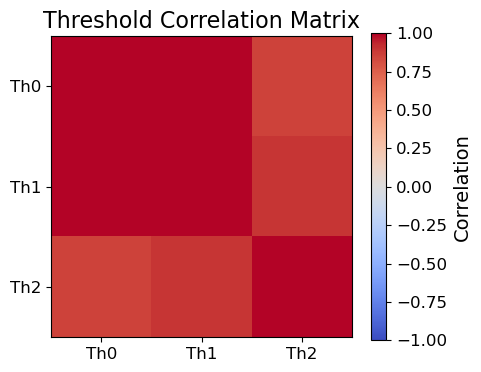

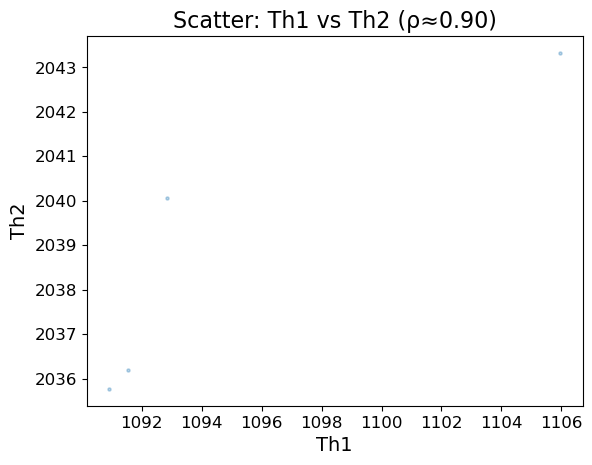

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Stack into (N,3) array
data = np.vstack([raw_th0, raw_th1, raw_th2]).T

# Correlation matrix
corr = np.corrcoef(data, rowvar=False)

print("Correlation matrix:")
print(corr)

# Heatmap
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(["Th0","Th1","Th2"])
ax.set_yticklabels(["Th0","Th1","Th2"])
plt.colorbar(im, ax=ax, label="Correlation")
plt.title("Threshold Correlation Matrix")
plt.tight_layout()
plt.show()


plt.scatter(raw_th1, raw_th2, alpha=0.3, s=5)
plt.xlabel("Th1")
plt.ylabel("Th2")
plt.title("Scatter: Th1 vs Th2 (ρ≈0.90)")
plt.show()




In [35]:
from sklearn.decomposition import PCA

data = np.vstack([raw_th0, raw_th1, raw_th2]).T
pca = PCA(n_components=3)
pca.fit(data)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Principal axes:\n", pca.components_)


Explained variance ratio: [9.83043481e-01 1.69460632e-02 1.04554454e-05]
Principal axes:
 [[ 0.81849339  0.52586061  0.23138537]
 [-0.3268205   0.09494447  0.94030522]
 [-0.47250072  0.84525509 -0.24957345]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to arrays
th0 = np.asarray(raw_th0, dtype=float)
th1 = np.asarray(raw_th1, dtype=float)
th2 = np.asarray(raw_th2, dtype=float)

# Compute differences
d01 = th0 - th1
d02 = th0 - th2
d12 = th1 - th2

# Choose common bins across all differences
all_diff = np.concatenate([d01, d02, d12])
bins = np.histogram_bin_edges(all_diff, bins=150)  # or bins=20

plt.figure(figsize=(8,6))
plt.hist(d12, bins=bins, alpha=0.5, label="Th1 - Th2", edgecolor="black")
plt.hist(d01, bins=bins, alpha=0.5, label="Th0 - Th1", edgecolor="black")
plt.hist(d02, bins=bins, alpha=0.5, label="Th0 - Th2", edgecolor="black")

plt.legend()
plt.xlabel("Difference (e⁻)")
plt.ylabel("Counts")
plt.title("Threshold Differences Across Events")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
